In [ ]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GroupKFold

* Dissolution tube [m]
* Dissolution pressure [Mpa]
* Discharge tube [m]
* Flow speed (oxygen) [mL/min]
* Flow speed (water) [mL/min]
* Water volume [mL]
* Sub Mean size [nm]
* Mode size [nm]
* NB concentration [×107 particles/ml]
* MB concentration [particles/mL]
* Size (bin) [_m]
* Oxygen content [mg/L]

In [ ]:
# K-Foldのサンプル数
n_splits = 5

In [ ]:
inputs = list()
teacher_signals = list()

with open("MB_data_v4.csv", "r") as f:
    r = csv.reader(f)
    for i, R in enumerate(r):
        if i == 0:
            R = [RR.strip().replace("\ufeff", "").replace("\n", "").replace("\u3000", "")
                 for RR in R]
            index = R
            print(index)
            continue

        R = list(map(float, R))
        inputs.append( R[:6] )
        teacher_signals.append( R[6:] )

inputs = np.array(inputs)
teacher_signals = np.array(teacher_signals)

#
inputs.shape, teacher_signals.shape

['Dissolve tube [m]', 'Dissolution pressure[Mpa]', 'Discharge tube[m]', 'Flow speed (oxygen)[mL/min]', 'Flow speed (water)[mL/min]', 'Water volume[mL]', 'Mean size[nm]', 'Mode size[nm]', 'NB concentration [×107 particles/ml](NB Mean)', 'MB concentration [particles/mL]', 'Size (bin) [µm]', 'Oxygen content[mg/L]']


((82, 6), (82, 6))

In [ ]:
ts_mean = np.mean(teacher_signals, axis = 0)
ts_std = np.std(teacher_signals, axis = 0)
i_mean = np.mean(inputs, axis = 0)
i_std = np.std(inputs, axis = 0)

# 標準化
normalized_teacher_signals = (teacher_signals - ts_mean) / ts_std
normalized_inputs = (inputs - i_mean) / i_std

# CV; 平均に対する分散の大きさ
CV = ts_std / ts_mean

# 郡内分散
cond_to_sumples = dict()
for I, T in zip(inputs, normalized_teacher_signals):
    I = tuple(I.tolist())
    if I in cond_to_sumples:
        cond_to_sumples[I].append(T)
    else:
        cond_to_sumples[I] = [T]

stds = list()
for I, T in cond_to_sumples.items():
    std = np.std(T, axis = 0)
    stds.append(std)

print("\t".join(index[6:]))
print("\t".join(list(map(str, CV))))
print("\t".join(list(map(str, np.mean(stds, axis = 0)))))

with open("tmp.tsv", "w") as f:
    f.write( "\t".join(index[6:]) + "\n" )
    f.write( "\t".join(list(map(str, CV))) + "\n" )
    f.write( "\t".join(list(map(str, np.mean(stds, axis = 0)))) )

Mean size[nm]	Mode size[nm]	NB concentration [×107 particles/ml](NB Mean)	MB concentration [particles/mL]	Size (bin) [µm]	Oxygen content[mg/L]
0.21618492735430347	0.22820318598349953	0.6363944553256558	0.6875226862056121	0.06804457649672713	0.11196226754892732
0.4495773213058574	0.45789126643917644	0.3491053066465943	0.16677279779829524	0.23589345945116988	0.2887711354472403


# MB concentration [particles/mL]を予測するモデル

# 線形回帰

train RMSE; 0.8652659710062908
test RMSE; 0.9359893080408653


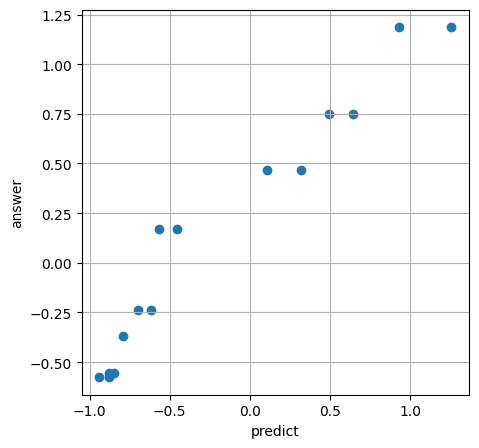

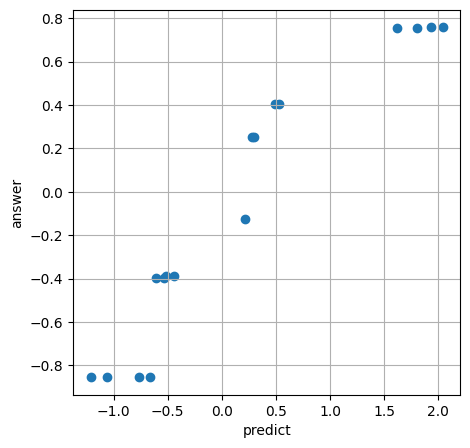

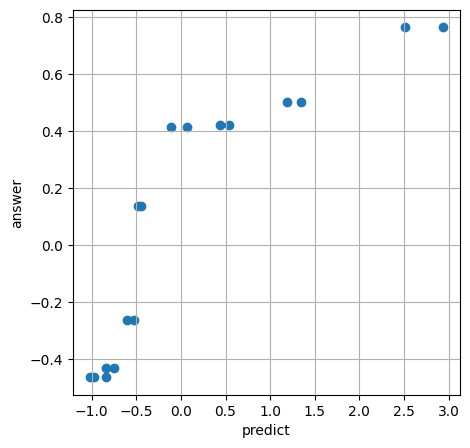

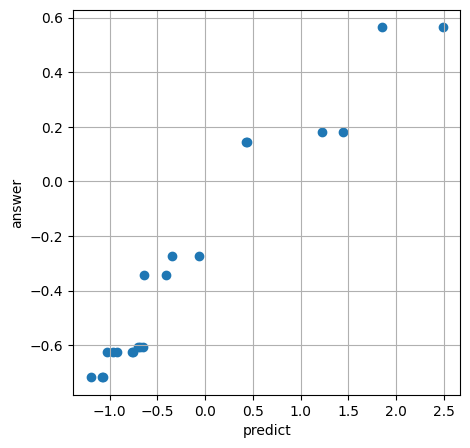

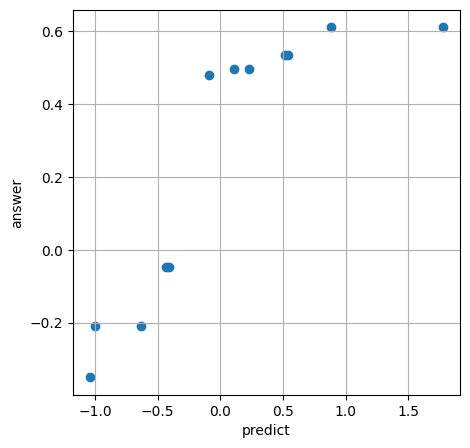

In [ ]:
# 入力が同じデータに同じインデックスを対応させる
cond_to_index = {
    C: i for i, C in enumerate(cond_to_sumples.keys())
}
groups = [
    cond_to_index[tuple(I.tolist())] for I in inputs
]

gkf = GroupKFold(n_splits = n_splits, random_state = 0, shuffle = True)

avg_train_loss = 0
avg_test_loss = 0

for train_idx, val_idx in gkf.split(inputs, normalized_teacher_signals,
                                    groups = groups):
    train_inputs, test_inputs = inputs[train_idx], inputs[val_idx]
    train_teacher_signals, test_teacher_signals  = normalized_teacher_signals[train_idx], normalized_teacher_signals[val_idx]

    # 3番目がMB concentration [particles/mL]
    y = train_teacher_signals[:, 3][..., np.newaxis]
    model = LinearRegression()
    model.fit(X = train_inputs,
              y = train_teacher_signals[:, 3][..., np.newaxis])

    # evaluation
    p = model.predict(np.array(train_inputs))
    train_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_train_loss += train_loss
    # print(f"train RMSE; {train_loss}")

    y = test_teacher_signals[:, 3][..., np.newaxis]
    p = model.predict(np.array(test_inputs))
    test_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_test_loss += test_loss
    # print(f"test RMSE; {test_loss}")
    # print("=" * 10)

    fig = plt.figure(figsize = (5, 5))
    ax = fig.add_subplot()
    ax.scatter(sorted(y), sorted(p))
    ax.set_xlabel("predict")
    ax.set_ylabel("answer")
    ax.grid()

print(f"train RMSE; {avg_train_loss / n_splits}")
print(f"test RMSE; {avg_test_loss / n_splits}")



# 多項式回帰(入力値そのものと入力値の直積を入力)

train RMSE; 0.5223691079292454
test RMSE; 0.7553601605442773


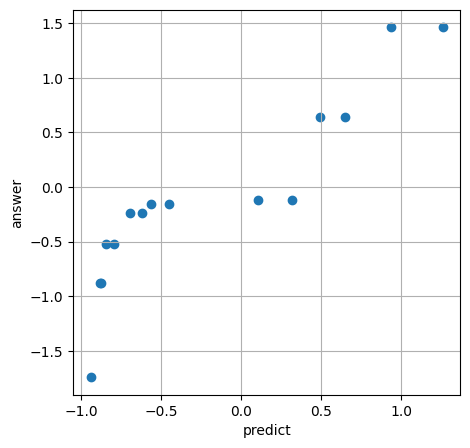

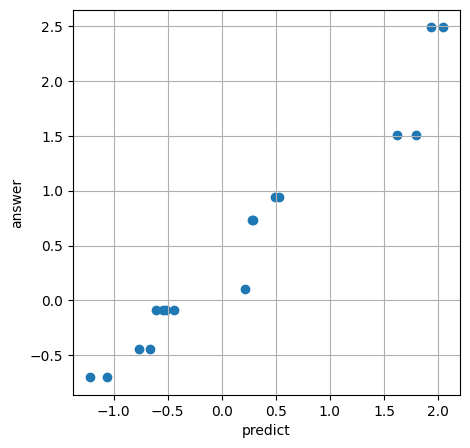

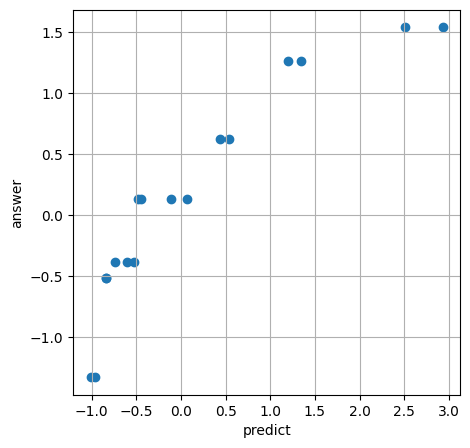

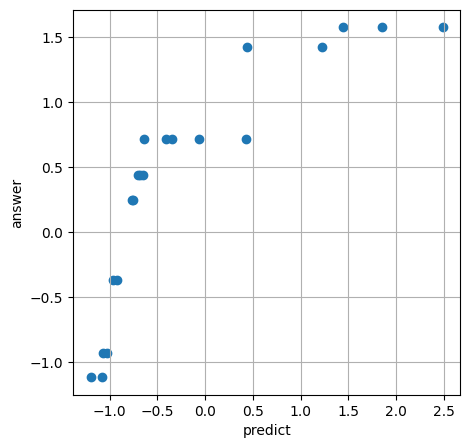

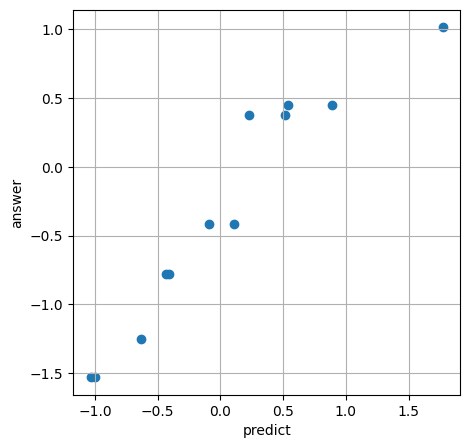

In [ ]:
# 入力が同じデータに同じインデックスを対応させる
cond_to_index = {
    C: i for i, C in enumerate(cond_to_sumples.keys())
}
groups = [
    cond_to_index[tuple(I.tolist())] for I in inputs
]

gkf = GroupKFold(n_splits = n_splits, random_state = 0, shuffle = True)

avg_train_loss = 0
avg_test_loss = 0

for train_idx, val_idx in gkf.split(inputs, normalized_teacher_signals,
                                    groups = groups):
    train_inputs, test_inputs = inputs[train_idx], inputs[val_idx]
    train_teacher_signals, test_teacher_signals  = normalized_teacher_signals[train_idx], normalized_teacher_signals[val_idx]

    # 3番目がMB concentration [particles/mL]
    y = train_teacher_signals[:, 3][..., np.newaxis]
    # 入力の各要素を二乗した変数を追加
    model = make_pipeline(PolynomialFeatures(2), LinearRegression())
    model.fit(X = train_inputs,
              y = train_teacher_signals[:, 3][..., np.newaxis])

    # evaluation
    p = model.predict(np.array(train_inputs))
    train_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_train_loss += train_loss
    # print(f"train RMSE; {train_loss}")

    y = test_teacher_signals[:, 3][..., np.newaxis]
    p = model.predict(np.array(test_inputs))
    test_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_test_loss += test_loss
    # print(f"test RMSE; {test_loss}")
    # print("=" * 10)

    fig = plt.figure(figsize = (5, 5))
    ax = fig.add_subplot()
    ax.scatter(sorted(y), sorted(p))
    ax.set_xlabel("predict")
    ax.set_ylabel("answer")
    ax.grid()

print(f"train RMSE; {avg_train_loss / n_splits}")
print(f"test RMSE; {avg_test_loss / n_splits}")



# Random Forest
* n_estimators = 10
* max_depth = 5

train RMSE; 0.3931429715415881
test RMSE; 0.6775660321646452


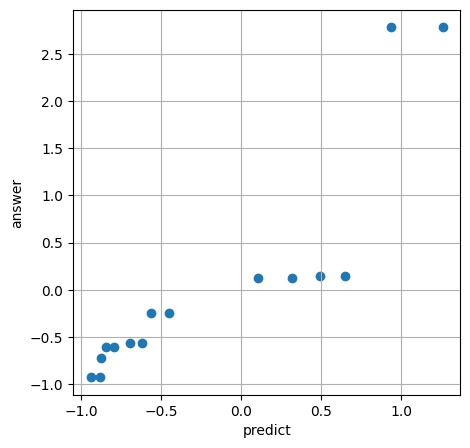

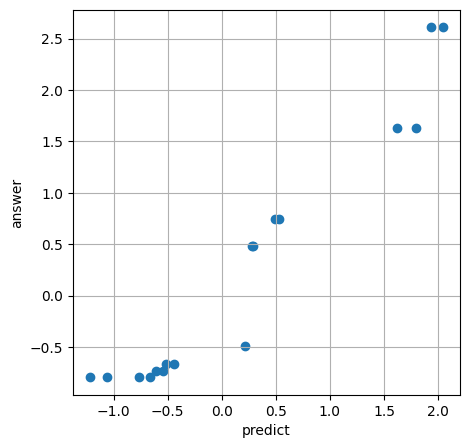

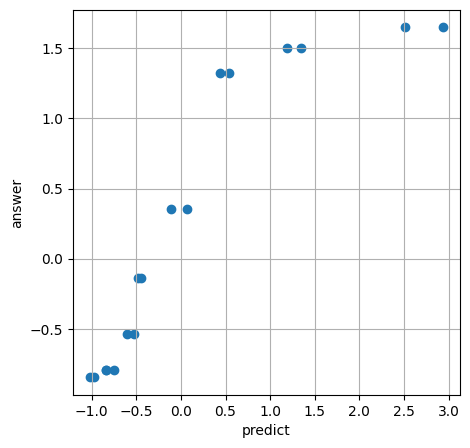

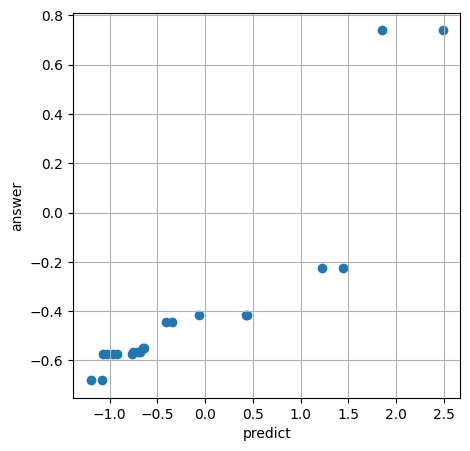

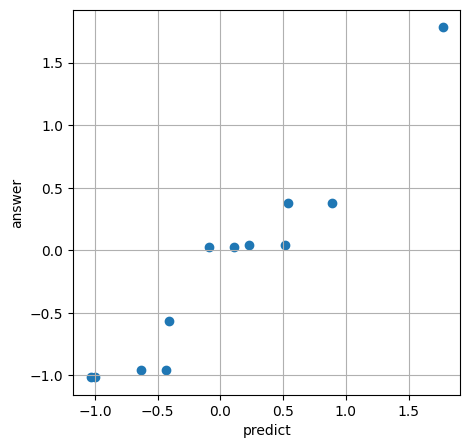

In [ ]:
# 入力が同じデータに同じインデックスを対応させる
cond_to_index = {
    C: i for i, C in enumerate(cond_to_sumples.keys())
}
groups = [
    cond_to_index[tuple(I.tolist())] for I in inputs
]

gkf = GroupKFold(n_splits = n_splits, random_state = 0, shuffle = True)

avg_train_loss = 0
avg_test_loss = 0

for train_idx, val_idx in gkf.split(inputs, normalized_teacher_signals,
                                    groups = groups):
    train_inputs, test_inputs = inputs[train_idx], inputs[val_idx]
    train_teacher_signals, test_teacher_signals  = normalized_teacher_signals[train_idx], normalized_teacher_signals[val_idx]

    # 3番目がMB concentration [particles/mL]
    y = train_teacher_signals[:, 3]
    # 入力の各要素を二乗した変数を追加
    model = RandomForestRegressor(
        n_estimators = 10,  # 木の本数
        max_depth = 5,    # 木の深さ（データが少ないなら 5〜10 くらいに制限すると過学習を防げます）
        random_state = 0
    )
    model.fit(X = train_inputs,
              y = train_teacher_signals[:, 3])

    # evaluation
    p = model.predict(np.array(train_inputs))
    train_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_train_loss += train_loss
    # print(f"train RMSE; {train_loss}")

    y = test_teacher_signals[:, 3]
    p = model.predict(np.array(test_inputs))
    test_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_test_loss += test_loss
    # print(f"test RMSE; {test_loss}")
    # print("=" * 10)

    fig = plt.figure(figsize = (5, 5))
    ax = fig.add_subplot()
    ax.scatter(sorted(y), sorted(p))
    ax.set_xlabel("predict")
    ax.set_ylabel("answer")
    ax.grid()

print(f"train RMSE; {avg_train_loss / n_splits}")
print(f"test RMSE; {avg_test_loss / n_splits}")



# Random Forest
* n_estimators = 10
* max_depth = 50

train RMSE; 0.37534970881542484
test RMSE; 0.6724975933557783


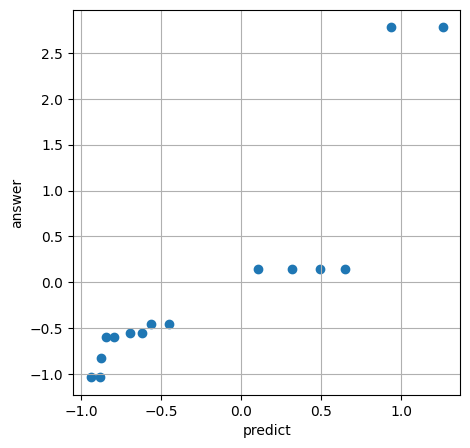

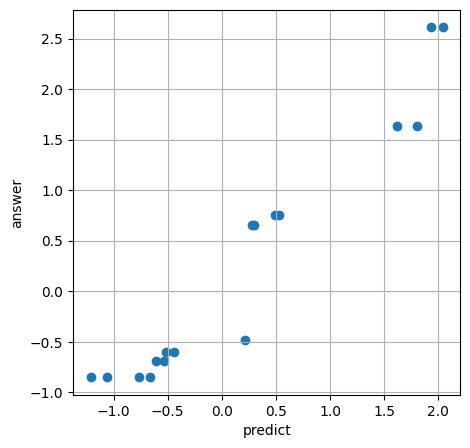

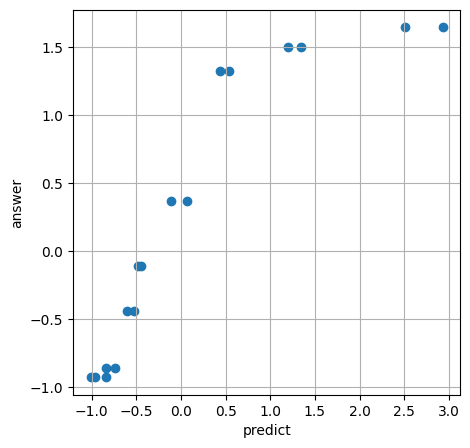

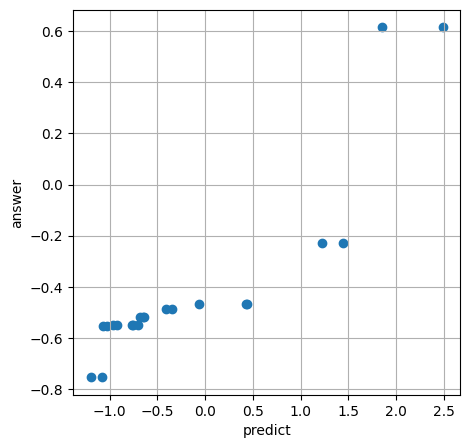

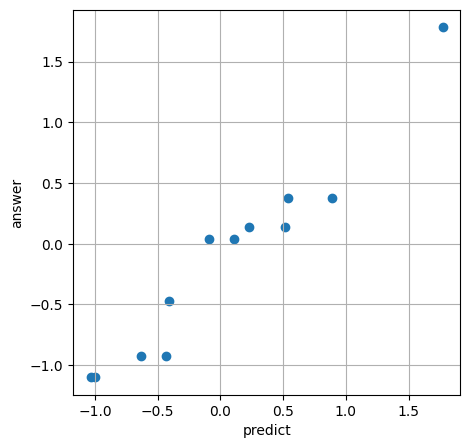

In [ ]:
# 入力が同じデータに同じインデックスを対応させる
cond_to_index = {
    C: i for i, C in enumerate(cond_to_sumples.keys())
}
groups = [
    cond_to_index[tuple(I.tolist())] for I in inputs
]

gkf = GroupKFold(n_splits = n_splits, random_state = 0, shuffle = True)

avg_train_loss = 0
avg_test_loss = 0

for train_idx, val_idx in gkf.split(inputs, normalized_teacher_signals,
                                    groups = groups):
    train_inputs, test_inputs = inputs[train_idx], inputs[val_idx]
    train_teacher_signals, test_teacher_signals  = normalized_teacher_signals[train_idx], normalized_teacher_signals[val_idx]

    # 3番目がMB concentration [particles/mL]
    y = train_teacher_signals[:, 3]
    # 入力の各要素を二乗した変数を追加
    model = RandomForestRegressor(
        n_estimators = 10,  # 木の本数
        max_depth = 50,    # 木の深さ（データが少ないなら 5〜10 くらいに制限すると過学習を防げます）
        random_state = 0
    )
    model.fit(X = train_inputs,
              y = train_teacher_signals[:, 3])

    # evaluation
    p = model.predict(np.array(train_inputs))
    train_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_train_loss += train_loss
    # print(f"train RMSE; {train_loss}")

    y = test_teacher_signals[:, 3]
    p = model.predict(np.array(test_inputs))
    test_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_test_loss += test_loss
    # print(f"test RMSE; {test_loss}")
    # print("=" * 10)

    fig = plt.figure(figsize = (5, 5))
    ax = fig.add_subplot()
    ax.scatter(sorted(y), sorted(p))
    ax.set_xlabel("predict")
    ax.set_ylabel("answer")
    ax.grid()

print(f"train RMSE; {avg_train_loss / n_splits}")
print(f"test RMSE; {avg_test_loss / n_splits}")



# Random Forest
* n_estimators = 100
* max_depth = 5

train RMSE; 0.3802247789081622
test RMSE; 0.6418303248091848


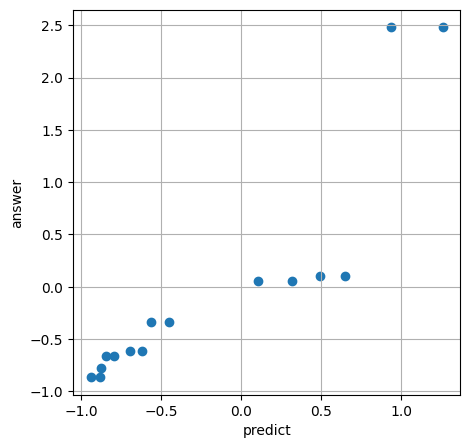

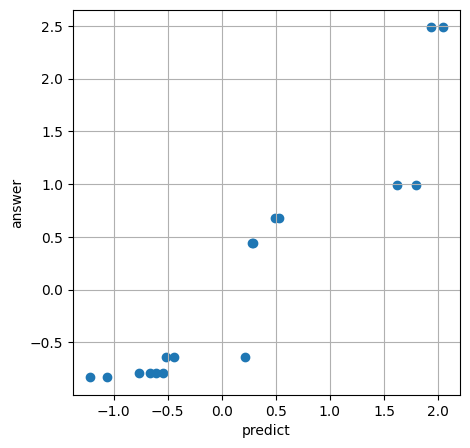

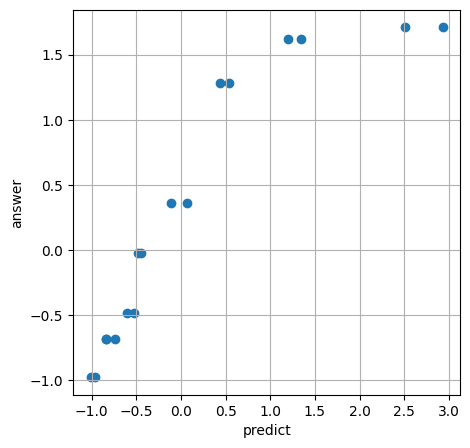

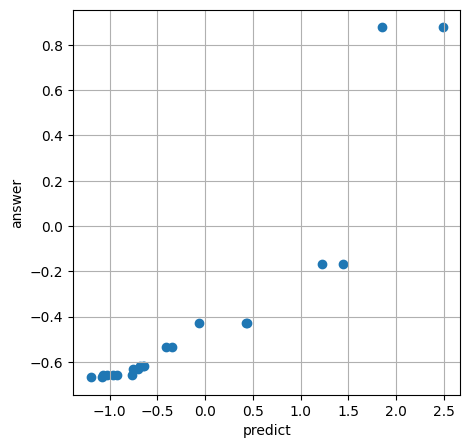

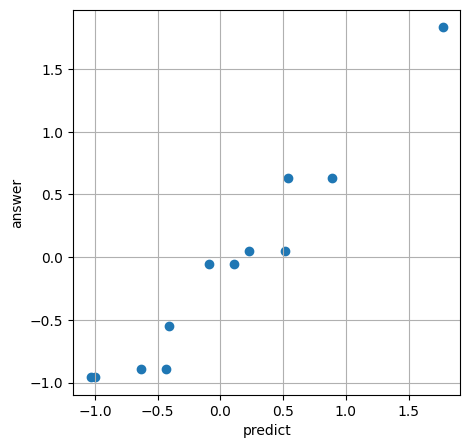

In [ ]:
# 入力が同じデータに同じインデックスを対応させる
cond_to_index = {
    C: i for i, C in enumerate(cond_to_sumples.keys())
}
groups = [
    cond_to_index[tuple(I.tolist())] for I in inputs
]

gkf = GroupKFold(n_splits = n_splits, random_state = 0, shuffle = True)

avg_train_loss = 0
avg_test_loss = 0

for train_idx, val_idx in gkf.split(inputs, normalized_teacher_signals,
                                    groups = groups):
    train_inputs, test_inputs = inputs[train_idx], inputs[val_idx]
    train_teacher_signals, test_teacher_signals  = normalized_teacher_signals[train_idx], normalized_teacher_signals[val_idx]

    # 3番目がMB concentration [particles/mL]
    y = train_teacher_signals[:, 3]
    # 入力の各要素を二乗した変数を追加
    model = RandomForestRegressor(
        n_estimators = 100,  # 木の本数
        max_depth = 5,    # 木の深さ（データが少ないなら 5〜10 くらいに制限すると過学習を防げます）
        random_state = 0
    )
    model.fit(X = train_inputs,
              y = train_teacher_signals[:, 3])

    # evaluation
    p = model.predict(np.array(train_inputs))
    train_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_train_loss += train_loss
    # print(f"train RMSE; {train_loss}")

    y = test_teacher_signals[:, 3]
    p = model.predict(np.array(test_inputs))
    test_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_test_loss += test_loss
    # print(f"test RMSE; {test_loss}")
    # print("=" * 10)

    fig = plt.figure(figsize = (5, 5))
    ax = fig.add_subplot()
    ax.scatter(sorted(y), sorted(p))
    ax.set_xlabel("predict")
    ax.set_ylabel("answer")
    ax.grid()

print(f"train RMSE; {avg_train_loss / n_splits}")
print(f"test RMSE; {avg_test_loss / n_splits}")



Dissolve tube [m]	Dissolution 
pressure[Mpa]	Discharge tube[m]	Flow speed 
(oxygen)[mL/min]	Flow speed
(water)[mL/min]	Water volume[mL]
0.030258816143008377	0.07787165049536413	0.6908361107765442	0.07961197372312806	0.08254048950087887	0.03888095936107627


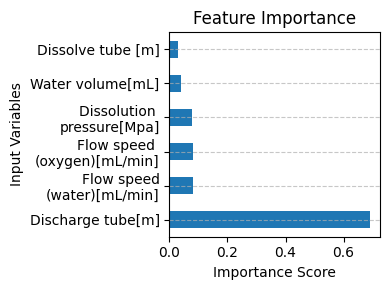

In [ ]:
importances = model.feature_importances_
feature_names = index[:6] # 入力変数の名前（カラム名）を指定
feature_names = [
"""Dissolve tube [m]""",
"""Dissolution
pressure[Mpa]""",
"""Discharge tube[m]""",
"""Flow speed
(oxygen)[mL/min]""",
"""Flow speed
(water)[mL/min]""",
"""Water volume[mL]"""
]

print("\t".join(feature_names))
print("\t".join(map(str, importances)))

# グラフ化
s = pd.Series(importances, index=feature_names).sort_values(ascending=False)

fig = plt.figure(figsize=(4, 3)) # サイズを少し調整すると見やすいです
ax = fig.add_subplot(111)

# axを指定してプロット
s.plot(kind='barh', ax=ax)

# axに対して装飾を行う
ax.set_title("Feature Importance")
ax.set_xlabel("Importance Score")
ax.set_ylabel("Input Variables")
ax.grid(axis='y', linestyle='--', alpha=0.7) # グリッドを入れると数値が読みやすくなります

plt.tight_layout() # ラベルの重なりを防ぐ
plt.show()

In [ ]:
feature_names = [
    """Dissolve tube [m]""",
    """Dissolution
       pressure[Mpa]""",
    """Discharge tube[m]""",
    """Flow speed
        (oxygen)[mL/min]""",
    """Flow speed
        (water)[mL/min]""",
    """Water volume[mL]"""
]

# Random Forest
* n_estimators = 100
* max_depth = 50

train RMSE; 0.3639521561749053
test RMSE; 0.6381534560696952


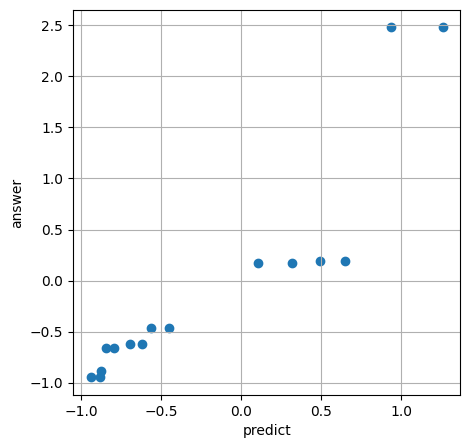

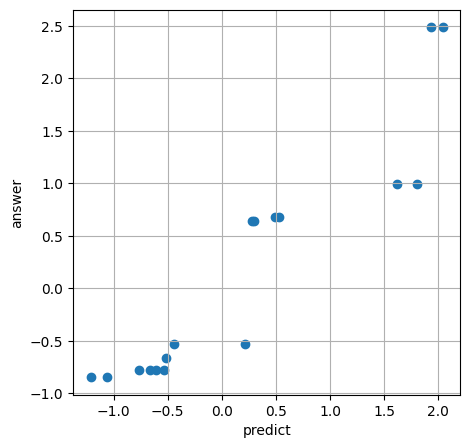

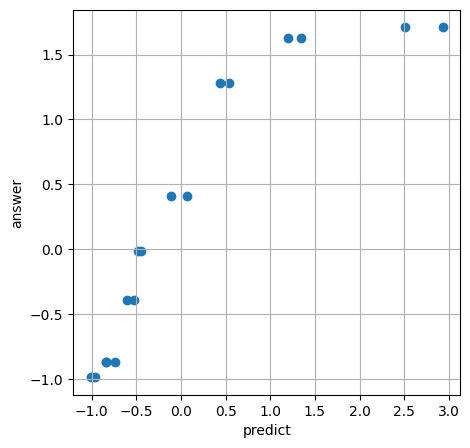

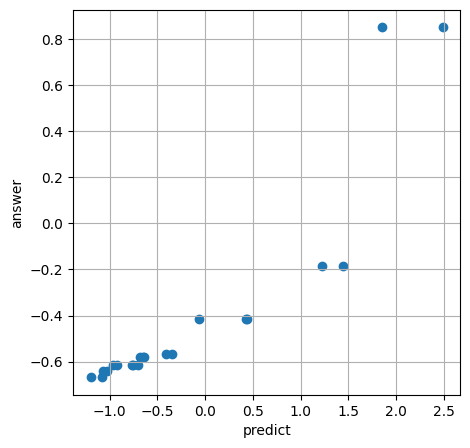

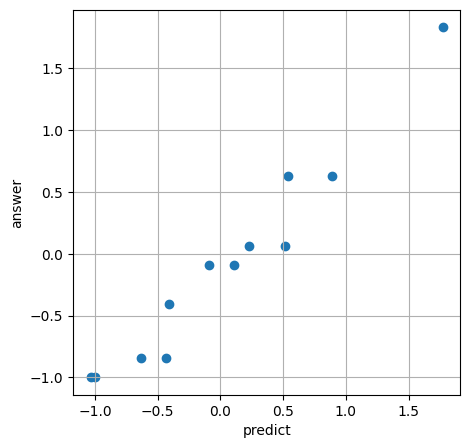

In [ ]:
# 入力が同じデータに同じインデックスを対応させる
cond_to_index = {
    C: i for i, C in enumerate(cond_to_sumples.keys())
}
groups = [
    cond_to_index[tuple(I.tolist())] for I in inputs
]

gkf = GroupKFold(n_splits = n_splits, random_state = 0, shuffle = True)

avg_train_loss = 0
avg_test_loss = 0

for train_idx, val_idx in gkf.split(inputs, normalized_teacher_signals,
                                    groups = groups):
    train_inputs, test_inputs = inputs[train_idx], inputs[val_idx]
    train_teacher_signals, test_teacher_signals  = normalized_teacher_signals[train_idx], normalized_teacher_signals[val_idx]

    # 3番目がMB concentration [particles/mL]
    y = train_teacher_signals[:, 3]
    # 入力の各要素を二乗した変数を追加
    model = RandomForestRegressor(
        n_estimators = 100,  # 木の本数
        max_depth = 50,    # 木の深さ（データが少ないなら 5〜10 くらいに制限すると過学習を防げます）
        random_state = 0
    )
    model.fit(X = train_inputs,
              y = train_teacher_signals[:, 3])

    # evaluation
    p = model.predict(np.array(train_inputs))
    train_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_train_loss += train_loss
    # print(f"train RMSE; {train_loss}")

    y = test_teacher_signals[:, 3]
    p = model.predict(np.array(test_inputs))
    test_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_test_loss += test_loss
    # print(f"test RMSE; {test_loss}")
    # print("=" * 10)

    fig = plt.figure(figsize = (5, 5))
    ax = fig.add_subplot()
    ax.scatter(sorted(y), sorted(p))
    ax.set_xlabel("predict")
    ax.set_ylabel("answer")
    ax.grid()

print(f"train RMSE; {avg_train_loss / n_splits}")
print(f"test RMSE; {avg_test_loss / n_splits}")



Dissolve tube [m]	Dissolution pressure[Mpa]	Discharge tube[m]	Flow speed (oxygen)[mL/min]	Flow speed (water)[mL/min]	Water volume[mL]
0.03339374898844935	0.08314782320693125	0.6799979028014078	0.08143728327382468	0.080142876859815	0.04188036486957181


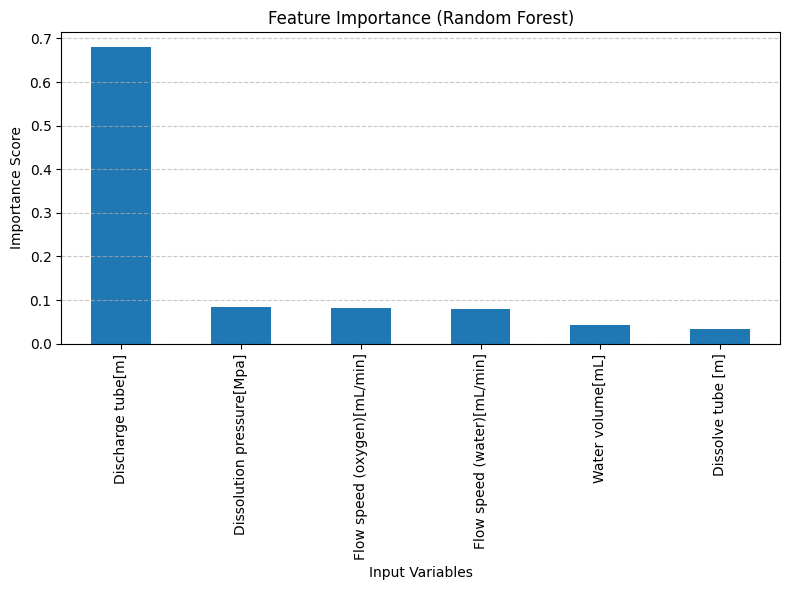

In [ ]:
importances = model.feature_importances_
feature_names = index[:6] # 入力変数の名前（カラム名）を指定

print("\t".join(feature_names))
print("\t".join(map(str, importances)))

# グラフ化
s = pd.Series(importances, index=feature_names).sort_values(ascending=False)

fig = plt.figure(figsize=(8, 6)) # サイズを少し調整すると見やすいです
ax = fig.add_subplot(111)

# axを指定してプロット
s.plot(kind='bar', ax=ax)

# axに対して装飾を行う
ax.set_title("Feature Importance (Random Forest)")
ax.set_ylabel("Importance Score")
ax.set_xlabel("Input Variables")
ax.grid(axis='y', linestyle='--', alpha=0.7) # グリッドを入れると数値が読みやすくなります

plt.tight_layout() # ラベルの重なりを防ぐ
plt.show()

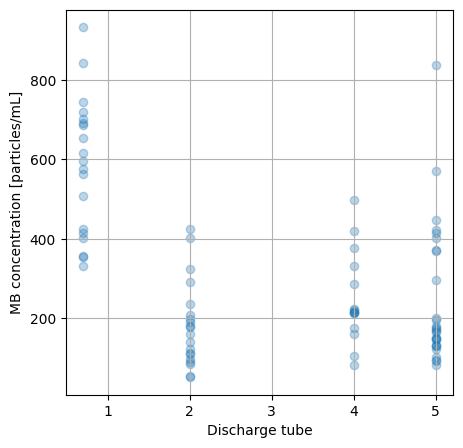

In [ ]:
fig = plt.figure(figsize = (5, 5))
ax = fig.add_subplot()
ax.scatter(inputs[:, 2], teacher_signals[:, 3], alpha = 0.3)
ax.set_xlabel("Discharge tube")
ax.set_ylabel("MB concentration [particles/mL]")
ax.grid()

# NB concentrationを予測するモデル

# Random Forest
* n_estimators = 100
* max_depth = 50

train RMSE; 0.5919464098983142
test RMSE; 0.8967764700214544


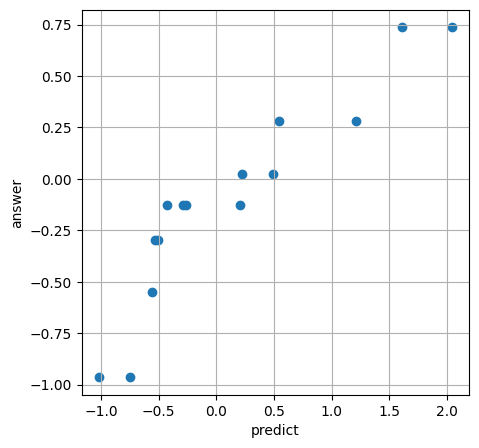

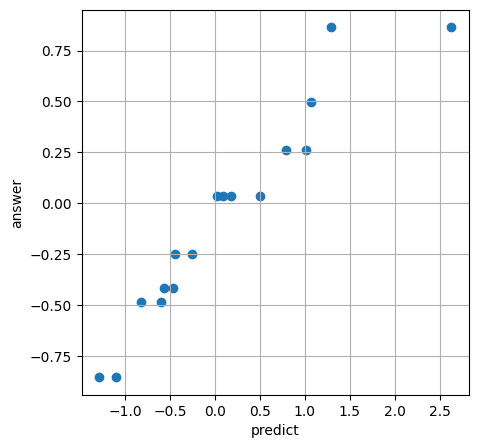

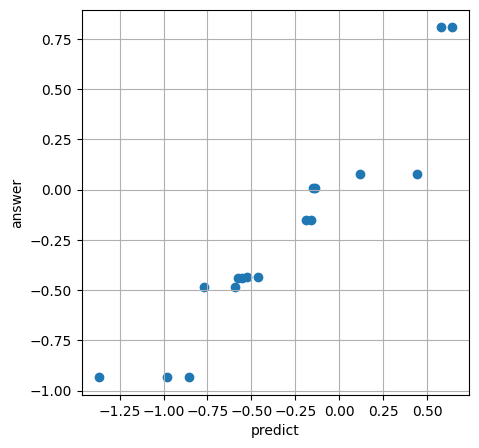

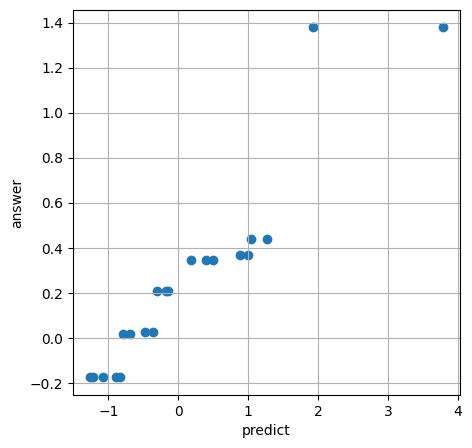

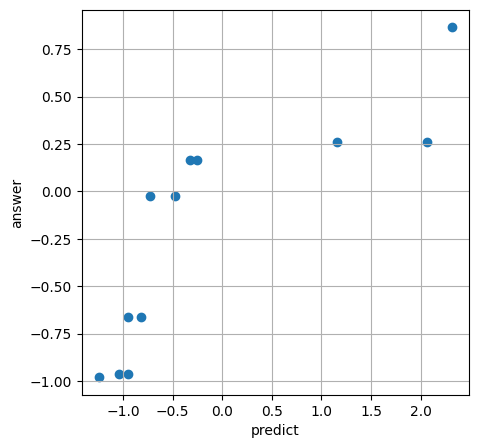

In [ ]:
# 入力が同じデータに同じインデックスを対応させる
cond_to_index = {
    C: i for i, C in enumerate(cond_to_sumples.keys())
}
groups = [
    cond_to_index[tuple(I.tolist())] for I in inputs
]

gkf = GroupKFold(n_splits = n_splits, random_state = 0, shuffle = True)

avg_train_loss = 0
avg_test_loss = 0

for train_idx, val_idx in gkf.split(inputs, normalized_teacher_signals,
                                    groups = groups):
    train_inputs, test_inputs = inputs[train_idx], inputs[val_idx]
    train_teacher_signals, test_teacher_signals  = normalized_teacher_signals[train_idx], normalized_teacher_signals[val_idx]

    # 2番目がNB concentration
    target_index = 2
    y = train_teacher_signals[:, target_index]
    # 入力の各要素を二乗した変数を追加
    model = RandomForestRegressor(
        n_estimators = 100,  # 木の本数
        max_depth = 50,    # 木の深さ（データが少ないなら 5〜10 くらいに制限すると過学習を防げます）
        random_state = 0
    )
    model.fit(X = train_inputs,
              y = train_teacher_signals[:, target_index])

    # evaluation
    p = model.predict(np.array(train_inputs))
    train_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_train_loss += train_loss
    # print(f"train RMSE; {train_loss}")

    y = test_teacher_signals[:, target_index]
    p = model.predict(np.array(test_inputs))
    test_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_test_loss += test_loss
    # print(f"test RMSE; {test_loss}")
    # print("=" * 10)

    fig = plt.figure(figsize = (5, 5))
    ax = fig.add_subplot()
    ax.scatter(sorted(y), sorted(p))
    ax.set_xlabel("predict")
    ax.set_ylabel("answer")
    ax.grid()

print(f"train RMSE; {avg_train_loss / n_splits}")
print(f"test RMSE; {avg_test_loss / n_splits}")



Dissolve tube [m]	Dissolution pressure[Mpa]	Discharge tube[m]	Flow speed (oxygen)[mL/min]	Flow speed (water)[mL/min]	Water volume[mL]
0.030814705001150383	0.21705735789791147	0.2280011530922659	0.1755617890268135	0.14667515436482512	0.20188984061703358


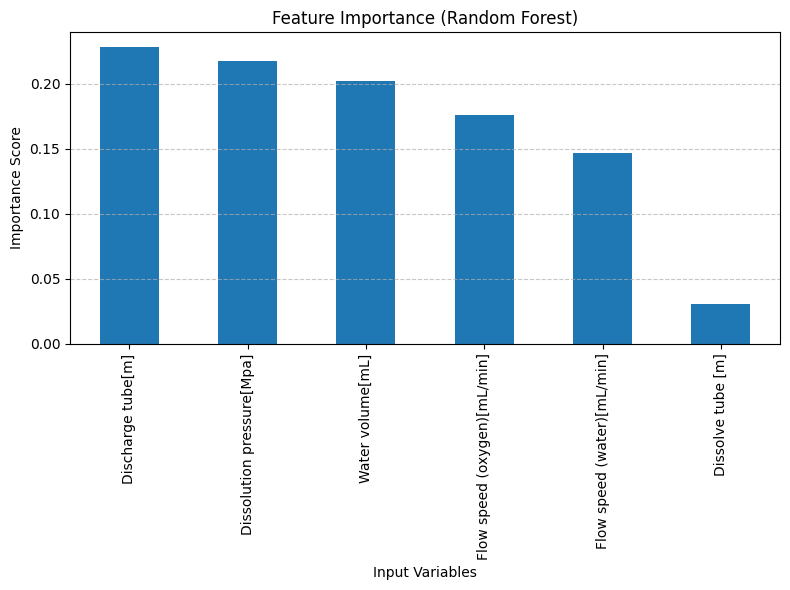

In [ ]:
importances = model.feature_importances_
feature_names = index[:6] # 入力変数の名前（カラム名）を指定

print("\t".join(feature_names))
print("\t".join(map(str, importances)))

# グラフ化
s = pd.Series(importances, index=feature_names).sort_values(ascending=False)

fig = plt.figure(figsize=(8, 6)) # サイズを少し調整すると見やすいです
ax = fig.add_subplot(111)

# axを指定してプロット
s.plot(kind='bar', ax=ax)

# axに対して装飾を行う
ax.set_title("Feature Importance (Random Forest)")
ax.set_ylabel("Importance Score")
ax.set_xlabel("Input Variables")
ax.grid(axis='y', linestyle='--', alpha=0.7) # グリッドを入れると数値が読みやすくなります

plt.tight_layout() # ラベルの重なりを防ぐ
plt.show()

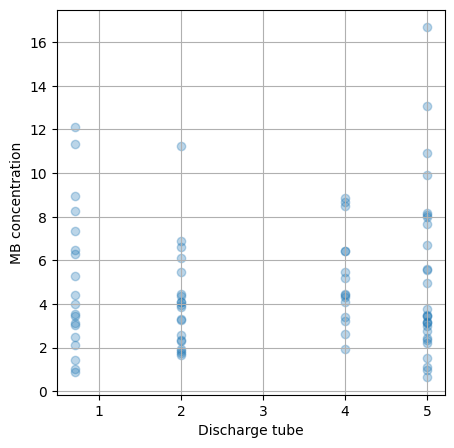

In [ ]:
fig = plt.figure(figsize = (5, 5))
ax = fig.add_subplot()
ax.scatter(inputs[:, 2], teacher_signals[:, 2], alpha = 0.3)
ax.set_xlabel("Discharge tube")
ax.set_ylabel("MB concentration")
ax.grid()

# 2026/6/23

MB conc.を線形回帰，多項式回帰(d = 2)，Random Forest(depth = 5, trees = 100)で学習

In [ ]:
# 3がMB conc.
target_idx = 3

# 入力が同じデータに同じインデックスを対応させる
cond_to_index = {
    C: i for i, C in enumerate(cond_to_sumples.keys())
}
groups = [
    cond_to_index[tuple(I.tolist())] for I in inputs
]

gkf = GroupKFold(n_splits = n_splits, random_state = 0, shuffle = True)

# 線形回帰
avg_train_loss = 0
avg_test_loss = 0
for train_idx, val_idx in gkf.split(inputs, normalized_teacher_signals,
                                    groups = groups):
    train_inputs, test_inputs = inputs[train_idx], inputs[val_idx]
    train_teacher_signals, test_teacher_signals  = normalized_teacher_signals[train_idx], normalized_teacher_signals[val_idx]

    y = train_teacher_signals[:, target_idx][..., np.newaxis]
    model = LinearRegression()
    model.fit(X = train_inputs,
              y = train_teacher_signals[:, target_idx][..., np.newaxis])

    # evaluation
    p = model.predict(np.array(train_inputs))
    train_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_train_loss += train_loss

    y = test_teacher_signals[:, target_idx][..., np.newaxis]
    p = model.predict(np.array(test_inputs))
    test_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_test_loss += test_loss

print("線形回帰")
print(f"train RMSE; {avg_train_loss / n_splits}")
print(f"test RMSE; {avg_test_loss / n_splits}")

# 多項式回帰(d = 2)
avg_train_loss = 0
avg_test_loss = 0
for train_idx, val_idx in gkf.split(inputs, normalized_teacher_signals,
                                    groups = groups):
    train_inputs, test_inputs = inputs[train_idx], inputs[val_idx]
    train_teacher_signals, test_teacher_signals  = normalized_teacher_signals[train_idx], normalized_teacher_signals[val_idx]

    # 3番目がMB concentration [particles/mL]
    y = train_teacher_signals[:, target_idx][..., np.newaxis]
    # 入力の各要素を二乗した変数を追加
    model = make_pipeline(PolynomialFeatures(2), LinearRegression())
    model.fit(X = train_inputs,
              y = train_teacher_signals[:, target_idx][..., np.newaxis])

    # evaluation
    p = model.predict(np.array(train_inputs))
    train_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_train_loss += train_loss

    y = test_teacher_signals[:, target_idx][..., np.newaxis]
    p = model.predict(np.array(test_inputs))
    test_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_test_loss += test_loss

print("多項式回帰")
print(f"train RMSE; {avg_train_loss / n_splits}")
print(f"test RMSE; {avg_test_loss / n_splits}")

# Random Forest
avg_train_loss = 0
avg_test_loss = 0
for train_idx, val_idx in gkf.split(inputs, normalized_teacher_signals,
                                    groups = groups):
    train_inputs, test_inputs = inputs[train_idx], inputs[val_idx]
    train_teacher_signals, test_teacher_signals  = normalized_teacher_signals[train_idx], normalized_teacher_signals[val_idx]

    y = train_teacher_signals[:, target_idx]
    # 入力の各要素を二乗した変数を追加
    model = RandomForestRegressor(
        n_estimators = 100,  # 木の本数
        max_depth = 5,    # 木の深さ（データが少ないなら 5〜10 くらいに制限すると過学習を防げます）
        random_state = 0
    )
    model.fit(X = train_inputs,
              y = train_teacher_signals[:, target_idx])

    # evaluation
    p = model.predict(np.array(train_inputs))
    train_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_train_loss += train_loss

    y = test_teacher_signals[:, target_idx]
    p = model.predict(np.array(test_inputs))
    test_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_test_loss += test_loss

print("random forest")
print(f"train RMSE; {avg_train_loss / n_splits}")
print(f"test RMSE; {avg_test_loss / n_splits}")



線形回帰
train RMSE; 0.8652659710062908
test RMSE; 0.9359893080408653
多項式回帰
train RMSE; 0.5223691079292454
test RMSE; 0.7553601605442773
random forest
train RMSE; 0.3802247789081622
test RMSE; 0.6418303248091848


Dissolve tube [m]	Dissolution pressure[Mpa]	Discharge tube[m]	Flow speed (oxygen)[mL/min]	Flow speed (water)[mL/min]	Water volume[mL]
0.030258816143008377	0.07787165049536413	0.6908361107765442	0.07961197372312806	0.08254048950087887	0.03888095936107627


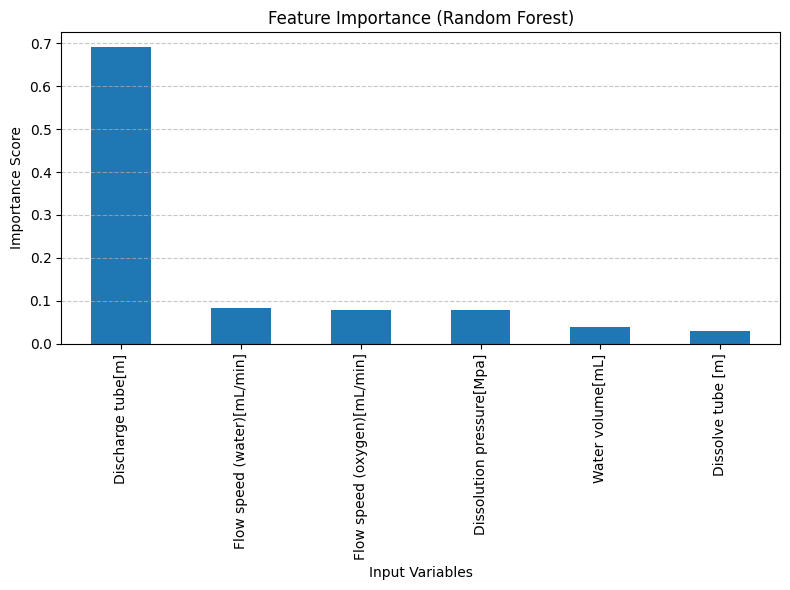

In [ ]:
importances = model.feature_importances_
feature_names = index[:6] # 入力変数の名前（カラム名）を指定

print("\t".join(feature_names))
print("\t".join(map(str, importances)))

# グラフ化
s = pd.Series(importances, index=feature_names).sort_values(ascending=False)

fig = plt.figure(figsize=(8, 6)) # サイズを少し調整すると見やすいです
ax = fig.add_subplot(111)

# axを指定してプロット
s.plot(kind='bar', ax=ax)

# axに対して装飾を行う
ax.set_title("Feature Importance (Random Forest)")
ax.set_ylabel("Importance Score")
ax.set_xlabel("Input Variables")
ax.grid(axis='y', linestyle='--', alpha=0.7) # グリッドを入れると数値が読みやすくなります

plt.tight_layout() # ラベルの重なりを防ぐ
plt.show()

NB conc.を線形回帰，多項式回帰(d = 2)，Random Forest(depth = 5, trees = 100)で学習

In [ ]:
# 2がNB conc.
target_idx = 2

# 入力が同じデータに同じインデックスを対応させる
cond_to_index = {
    C: i for i, C in enumerate(cond_to_sumples.keys())
}
groups = [
    cond_to_index[tuple(I.tolist())] for I in inputs
]

gkf = GroupKFold(n_splits = n_splits, random_state = 0, shuffle = True)

# 線形回帰
avg_train_loss = 0
avg_test_loss = 0
for train_idx, val_idx in gkf.split(inputs, normalized_teacher_signals,
                                    groups = groups):
    train_inputs, test_inputs = inputs[train_idx], inputs[val_idx]
    train_teacher_signals, test_teacher_signals  = normalized_teacher_signals[train_idx], normalized_teacher_signals[val_idx]

    y = train_teacher_signals[:, target_idx][..., np.newaxis]
    model = LinearRegression()
    model.fit(X = train_inputs,
              y = train_teacher_signals[:, target_idx][..., np.newaxis])

    # evaluation
    p = model.predict(np.array(train_inputs))
    train_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_train_loss += train_loss

    y = test_teacher_signals[:, target_idx][..., np.newaxis]
    p = model.predict(np.array(test_inputs))
    test_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_test_loss += test_loss

print("線形回帰")
print(f"train RMSE; {avg_train_loss / n_splits}")
print(f"test RMSE; {avg_test_loss / n_splits}")

# 多項式回帰(d = 2)
avg_train_loss = 0
avg_test_loss = 0
for train_idx, val_idx in gkf.split(inputs, normalized_teacher_signals,
                                    groups = groups):
    train_inputs, test_inputs = inputs[train_idx], inputs[val_idx]
    train_teacher_signals, test_teacher_signals  = normalized_teacher_signals[train_idx], normalized_teacher_signals[val_idx]

    # 3番目がMB concentration [particles/mL]
    y = train_teacher_signals[:, target_idx][..., np.newaxis]
    # 入力の各要素を二乗した変数を追加
    model = make_pipeline(PolynomialFeatures(2), LinearRegression())
    model.fit(X = train_inputs,
              y = train_teacher_signals[:, target_idx][..., np.newaxis])

    # evaluation
    p = model.predict(np.array(train_inputs))
    train_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_train_loss += train_loss

    y = test_teacher_signals[:, target_idx][..., np.newaxis]
    p = model.predict(np.array(test_inputs))
    test_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_test_loss += test_loss

print("多項式回帰")
print(f"train RMSE; {avg_train_loss / n_splits}")
print(f"test RMSE; {avg_test_loss / n_splits}")

# Random Forest
avg_train_loss = 0
avg_test_loss = 0
for train_idx, val_idx in gkf.split(inputs, normalized_teacher_signals,
                                    groups = groups):
    train_inputs, test_inputs = inputs[train_idx], inputs[val_idx]
    train_teacher_signals, test_teacher_signals  = normalized_teacher_signals[train_idx], normalized_teacher_signals[val_idx]

    y = train_teacher_signals[:, target_idx]
    # 入力の各要素を二乗した変数を追加
    model = RandomForestRegressor(
        n_estimators = 100,  # 木の本数
        max_depth = 5,    # 木の深さ（データが少ないなら 5〜10 くらいに制限すると過学習を防げます）
        random_state = 0
    )
    model.fit(X = train_inputs,
              y = train_teacher_signals[:, target_idx])

    # evaluation
    p = model.predict(np.array(train_inputs))
    train_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_train_loss += train_loss

    y = test_teacher_signals[:, target_idx]
    p = model.predict(np.array(test_inputs))
    test_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_test_loss += test_loss

print("random forest")
print(f"train RMSE; {avg_train_loss / n_splits}")
print(f"test RMSE; {avg_test_loss / n_splits}")



線形回帰
train RMSE; 0.8440752776962517
test RMSE; 0.9562973163739079
多項式回帰
train RMSE; 0.6946572994724514
test RMSE; 1.1680238037310167
random forest
train RMSE; 0.6184300400843092
test RMSE; 0.8854528322579659


Dissolve tube [m]	Dissolution pressure[Mpa]	Discharge tube[m]	Flow speed (oxygen)[mL/min]	Flow speed (water)[mL/min]	Water volume[mL]
0.027269384813699424	0.2339838113444113	0.19561018652778084	0.17754210764088482	0.14208009768464705	0.22351441198857644


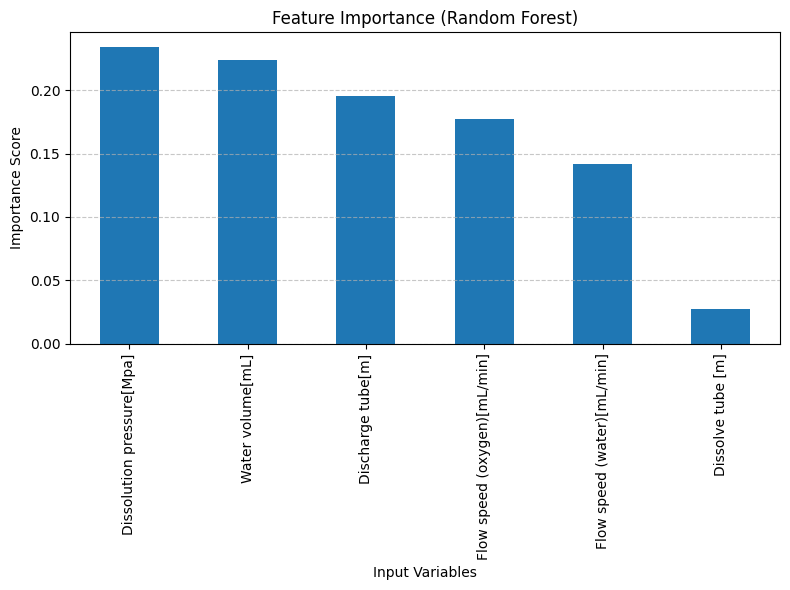

In [ ]:
importances = model.feature_importances_
feature_names = index[:6] # 入力変数の名前（カラム名）を指定

print("\t".join(feature_names))
print("\t".join(map(str, importances)))

# グラフ化
s = pd.Series(importances, index=feature_names).sort_values(ascending=False)

fig = plt.figure(figsize=(8, 6)) # サイズを少し調整すると見やすいです
ax = fig.add_subplot(111)

# axを指定してプロット
s.plot(kind='bar', ax=ax)

# axに対して装飾を行う
ax.set_title("Feature Importance (Random Forest)")
ax.set_ylabel("Importance Score")
ax.set_xlabel("Input Variables")
ax.grid(axis='y', linestyle='--', alpha=0.7) # グリッドを入れると数値が読みやすくなります

plt.tight_layout() # ラベルの重なりを防ぐ
plt.show()

Oxygen cont.を線形回帰，多項式回帰(d = 2)，Random Forest(depth = 5, trees = 100)で学習

In [ ]:
# 5がOxygen cont.
target_idx = 5

# 入力が同じデータに同じインデックスを対応させる
cond_to_index = {
    C: i for i, C in enumerate(cond_to_sumples.keys())
}
groups = [
    cond_to_index[tuple(I.tolist())] for I in inputs
]

gkf = GroupKFold(n_splits = n_splits, random_state = 0, shuffle = True)

# 線形回帰
avg_train_loss = 0
avg_test_loss = 0
for train_idx, val_idx in gkf.split(inputs, normalized_teacher_signals,
                                    groups = groups):
    train_inputs, test_inputs = inputs[train_idx], inputs[val_idx]
    train_teacher_signals, test_teacher_signals  = normalized_teacher_signals[train_idx], normalized_teacher_signals[val_idx]

    y = train_teacher_signals[:, target_idx][..., np.newaxis]
    model = LinearRegression()
    model.fit(X = train_inputs,
              y = train_teacher_signals[:, target_idx][..., np.newaxis])

    # evaluation
    p = model.predict(np.array(train_inputs))
    train_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_train_loss += train_loss

    y = test_teacher_signals[:, target_idx][..., np.newaxis]
    p = model.predict(np.array(test_inputs))
    test_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_test_loss += test_loss

print("線形回帰")
print(f"train RMSE; {avg_train_loss / n_splits}")
print(f"test RMSE; {avg_test_loss / n_splits}")

# 多項式回帰(d = 2)
avg_train_loss = 0
avg_test_loss = 0
for train_idx, val_idx in gkf.split(inputs, normalized_teacher_signals,
                                    groups = groups):
    train_inputs, test_inputs = inputs[train_idx], inputs[val_idx]
    train_teacher_signals, test_teacher_signals  = normalized_teacher_signals[train_idx], normalized_teacher_signals[val_idx]

    # 3番目がMB concentration [particles/mL]
    y = train_teacher_signals[:, target_idx][..., np.newaxis]
    # 入力の各要素を二乗した変数を追加
    model = make_pipeline(PolynomialFeatures(2), LinearRegression())
    model.fit(X = train_inputs,
              y = train_teacher_signals[:, target_idx][..., np.newaxis])

    # evaluation
    p = model.predict(np.array(train_inputs))
    train_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_train_loss += train_loss

    y = test_teacher_signals[:, target_idx][..., np.newaxis]
    p = model.predict(np.array(test_inputs))
    test_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_test_loss += test_loss

print("多項式回帰")
print(f"train RMSE; {avg_train_loss / n_splits}")
print(f"test RMSE; {avg_test_loss / n_splits}")

# Random Forest
avg_train_loss = 0
avg_test_loss = 0
for train_idx, val_idx in gkf.split(inputs, normalized_teacher_signals,
                                    groups = groups):
    train_inputs, test_inputs = inputs[train_idx], inputs[val_idx]
    train_teacher_signals, test_teacher_signals  = normalized_teacher_signals[train_idx], normalized_teacher_signals[val_idx]

    y = train_teacher_signals[:, target_idx]
    # 入力の各要素を二乗した変数を追加
    model = RandomForestRegressor(
        n_estimators = 100,  # 木の本数
        max_depth = 5,    # 木の深さ（データが少ないなら 5〜10 くらいに制限すると過学習を防げます）
        random_state = 0
    )
    model.fit(X = train_inputs,
              y = train_teacher_signals[:, target_idx])

    # evaluation
    p = model.predict(np.array(train_inputs))
    train_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_train_loss += train_loss

    y = test_teacher_signals[:, target_idx]
    p = model.predict(np.array(test_inputs))
    test_loss = np.sqrt(np.mean((p - y) ** 2))
    avg_test_loss += test_loss

print("random forest")
print(f"train RMSE; {avg_train_loss / n_splits}")
print(f"test RMSE; {avg_test_loss / n_splits}")



線形回帰
train RMSE; 0.6753526948980495
test RMSE; 0.7497759173987004
多項式回帰
train RMSE; 0.5094684221031804
test RMSE; 0.7915428539169124
random forest
train RMSE; 0.46119780508513186
test RMSE; 0.6836997676955668


Dissolve tube [m]	Dissolution pressure[Mpa]	Discharge tube[m]	Flow speed (oxygen)[mL/min]	Flow speed (water)[mL/min]	Water volume[mL]
0.030618080145028384	0.05554308259757273	0.760984754911295	0.06466414746004417	0.06683411342234151	0.021355821463718328


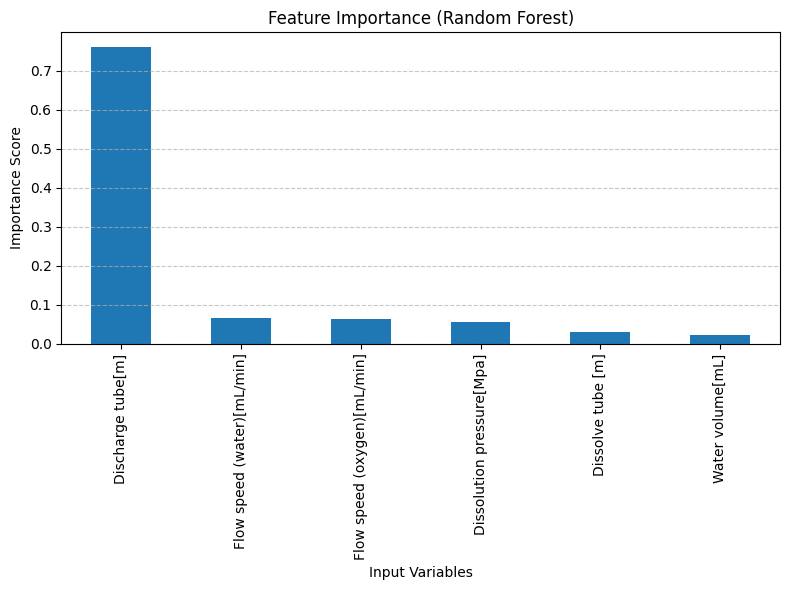

In [ ]:
importances = model.feature_importances_
feature_names = index[:6] # 入力変数の名前（カラム名）を指定

print("\t".join(feature_names))
print("\t".join(map(str, importances)))

# グラフ化
s = pd.Series(importances, index=feature_names).sort_values(ascending=False)

fig = plt.figure(figsize=(8, 6)) # サイズを少し調整すると見やすいです
ax = fig.add_subplot(111)

# axを指定してプロット
s.plot(kind='bar', ax=ax)

# axに対して装飾を行う
ax.set_title("Feature Importance (Random Forest)")
ax.set_ylabel("Importance Score")
ax.set_xlabel("Input Variables")
ax.grid(axis='y', linestyle='--', alpha=0.7) # グリッドを入れると数値が読みやすくなります

plt.tight_layout() # ラベルの重なりを防ぐ
plt.show()